# LOBdata_RL_v2 — Finer discrete action space for the live-ABIDES PPO execution agent

Companion to `data/LOBdata_RL_v1.ipynb` (richer observation space) and
`LOBdata_EDA.ipynb` Part 10 (the original live-ABIDES benchmark) — a separate
notebook, same convention: one isolated change at a time, same market, same agents,
same training recipe.

**Motivation**: reviewing v1's actual trained behavior (not just its aggregate
benchmark numbers) against a literature-informed critique found a real problem
neither v0 nor v1 touched — the **action space**. `DEFAULT_ACTION_SHARES = {0: 0,
1: 500, 2: 2500, 3: 5000}` has a large gap between 500 and 2,500 shares. Checking the
actual action distribution of both trained v1 checkpoints (10 test-seed rollouts
each) found the policy uses **only actions 0 (hold) and 1 (500 shares) — literally
0% usage of the 2,500 or 5,000-share actions**, for both variants. The policy
couldn't cleanly size a trade to the book it was actually facing, so it collapsed
entirely to the one size it could reliably control.

A companion finding, verified analytically: the one-step reward's marginal math
(`r_inv = -phi * i_t**2`, `r_slip = -slip_bps * step_filled/total_shares`) only
rewards trading over holding when `slip_bps < 2 * phi * i_t` — at `phi=0.03`,
`i_t≈1`, that's a ~0.06bps threshold, far below any real trade's slippage. This is a
real design tension but is **deliberately deferred** to a later, isolated change
(see Decisions below) rather than fixed in the same round as the action space, so any
effect below can be cleanly attributed to one variable — the same discipline
`LOBdata_EDA.ipynb` Part 7 had to relearn after bundling two reward changes together
and being unable to tell which one did the work.

**Decisions made before implementing** (full reasoning in the plan used to scope
this):
1. **Finer discrete bins, not continuous, for this round.** The env already accepts
   a custom `action_shares` dict via an existing, previously-unused constructor
   parameter — a finer grid needs no change to the action-selection code path, only
   a new dict. Continuous (`spaces.Box`) would need real new code plus untested
   PPO-continuous-mode training dynamics in this codebase; deferred as a v3
   candidate if finer bins don't fully resolve the collapse.
2. **Action space only this round** — `phi`/`r_inv` stay exactly as v1. The
   time-scaled urgency penalty implied by the reward-math finding above is a
   separate, isolated follow-up candidate, not bundled in here.
3. **Observation space unchanged from v1** (`BASE_FEATURE_COLS`, 11/12-dim) — v2 is
   v1's observation space + a new action space, isolating the action-space variable
   against the most recent baseline, not reverting to v0.

## v1 recap: the action-distribution collapse that motivated this

Both v1 checkpoints, deterministic policy, 10 test-seed rollouts each:

In [1]:
from stable_baselines3 import PPO
from collections import Counter
from abides_sim.gym_env import ABIDESExecutionEnv

model_no_oracle_v1 = PPO.load("ppo_no_oracle_v1_final")
model_with_oracle_v1 = PPO.load("ppo_with_oracle_v1_final")

for label, model, use_oracle in [("v1 no-oracle", model_no_oracle_v1, False), ("v1 with-oracle", model_with_oracle_v1, True)]:
    action_counts = Counter()
    for seed in range(1, 11):
        env = ABIDESExecutionEnv(
            total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
            oracle_predict_fn=oracle if use_oracle else None, phi=0.03, psi=1.0,
            market_kwargs=dict(symbol="ABM"),
        )
        obs, _ = env.reset(seed=seed)
        terminated = False
        while not terminated:
            action, _ = model.predict(obs, deterministic=True)
            action_counts[int(action)] += 1
            obs, reward, terminated, truncated, info = env.step(action)
    total = sum(action_counts.values())
    print(f"{label}: total decisions={total}")
    for a in sorted(action_counts):
        shares = {0:0,1:500,2:2500,3:5000}[a]
        print(f"  action={a} ({shares:5d} shares): {action_counts[a]:4d} times ({100*action_counts[a]/total:.1f}%)")
    print()

v1 no-oracle: total decisions=291
  action=0 (    0 shares):   88 times (30.2%)
  action=1 (  500 shares):  203 times (69.8%)

v1 with-oracle: total decisions=328
  action=0 (    0 shares):  128 times (39.0%)
  action=1 (  500 shares):  200 times (61.0%)



## 1. Calibrating the new bins against actual resting depth

Before picking bin edges, measure the actual distribution rather than guess. This
samples Level-1 ask-side resting depth (the side a buy order walks) across live
episodes with a hold-only agent, so the logged depth reflects the background
market's own natural liquidity, not depth the agent has already consumed.

In [1]:
import numpy as np

depths = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated, steps = False, 0
    while not terminated and steps < 40:
        _, _, _, ask_vol = env.gym_agent.get_known_bid_ask("ABM")
        if ask_vol:
            depths.append(ask_vol)
        obs, reward, terminated, truncated, info = env.step(0)  # hold-only: don't consume the depth being measured
        steps += 1

depths = np.array(depths)
print(f"n={len(depths)} ticks sampled across 10 episodes")
print("percentiles (ask-side L1 resting depth, shares):")
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:2d}: {np.percentile(depths, p):8.0f}")
print("mean:", depths.mean(), " max:", depths.max())

n=400 ticks sampled across 10 episodes
percentiles (ask-side L1 resting depth, shares):
  p 5:        5
  p10:        9
  p25:       23
  p50:       48
  p75:       88
  p90:      166
  p95:      210
  p99:      276
mean: 192.025  max: 49680


**Surprising result that reshaped the whole design**: typical L1 depth is far
smaller than assumed — median **48 shares**, p90 **166**, p99 **276** (mean of 192 is
skewed by rare bursts up to ~50k). DEFAULT_ACTION_SHARES's smallest nonzero action
(500) already exceeds the 99th percentile of what's typically resting — the agent
never had a way to size a trade to the book it was actually facing. This also means
"sweep exactly L1" is essentially never achievable at this order size (10,000 shares
over up to 40 steps needs ~250/step average pace, itself several times typical L1
depth) — walking multiple levels is close to unavoidable regardless of bin choice
above a few hundred shares. The design goal became fine control specifically in the
regime that matters (0-350 shares, where finer resolution changes which levels get
walked), not dense coverage of a much larger range where it wouldn't.

## 2. `FINE_ACTION_SHARES`

```python
FINE_ACTION_SHARES = {
    0: 0, 1: 50, 2: 100, 3: 200, 4: 350, 5: 500,
    6: 750, 7: 1000, 8: 1500, 9: 2500, 10: 4000, 11: 5000,
}
```

Ceiling stays at 5,000 (unchanged from v0/v1 — not increasing the risk envelope,
just filling in the gap below it). Bins below 350 densely bracket the measured
depth distribution; above that, walking multiple levels is unavoidable at this order
size regardless of bin choice, so the remaining bins climb geometrically rather than
trying to densely cover a range where finer resolution wouldn't change behavior.

No other code changes were needed: `RLExecutionAgent`'s and `ABIDESExecutionEnv`'s
existing (previously unused) `action_shares` constructor parameter already threads
through to `apply_actions()` and `self.action_space = spaces.Discrete(len(self.action_shares))`
already auto-sizes to whatever dict is passed — confirmed by reading both call sites
before writing anything.

In [1]:
from abides_sim.gym_env import FINE_ACTION_SHARES

print("FINE_ACTION_SHARES:", FINE_ACTION_SHARES)
for k, v in FINE_ACTION_SHARES.items():
    pct = (depths <= v).mean() * 100 if v > 0 else 0.0
    print(f"  action {k:2d}: {v:5d} shares -> covers {pct:5.1f}th percentile of observed L1 depth")

FINE_ACTION_SHARES: {0: 0, 1: 50, 2: 100, 3: 200, 4: 350, 5: 500, 6: 750, 7: 1000, 8: 1500, 9: 2500, 10: 4000, 11: 5000}
  action  0:     0 shares -> covers   0.0th percentile of observed L1 depth
  action  1:    50 shares -> covers  51.7th percentile of observed L1 depth
  action  2:   100 shares -> covers  79.5th percentile of observed L1 depth
  action  3:   200 shares -> covers  93.8th percentile of observed L1 depth
  action  4:   350 shares -> covers  99.8th percentile of observed L1 depth
  action  5:   500 shares -> covers  99.8th percentile of observed L1 depth
  action  6:   750 shares -> covers  99.8th percentile of observed L1 depth
  action  7:  1000 shares -> covers  99.8th percentile of observed L1 depth
  action  8:  1500 shares -> covers  99.8th percentile of observed L1 depth
  action  9:  2500 shares -> covers  99.8th percentile of observed L1 depth
  action 10:  4000 shares -> covers  99.8th percentile of observed L1 depth
  action 11:  5000 shares -> covers  99.8th

## 3. Training

Same recipe as v1's final `phi=0.03` run, every hyperparameter held fixed so the
only variable vs. v1 is the action space — `horizon_steps=40, phi=0.03, psi=1.0,`
1000 episodes, `n_envs=8`, a snapshot every 100 episodes. Run outside the notebook
(background jobs):

```python
# no-oracle
train_ppo_agent(
    target_episodes=1000, seed=0, checkpoint_path="data/ppo_no_oracle_v2_phi003",
    env_kwargs=dict(total_shares=10_000, horizon_steps=40, window_minutes=45,
                     step_interval="1min", action_shares=FINE_ACTION_SHARES, phi=0.03, psi=1.0),
    tensorboard_log="data/tb_logs", run_name="no_oracle_v2_phi003_1000",
    n_envs=8, snapshot_every=100,
)

# with-oracle
train_ppo_agent(
    target_episodes=1000, seed=0, checkpoint_path="data/ppo_with_oracle_v2_phi003",
    env_kwargs=dict(total_shares=10_000, horizon_steps=40, window_minutes=45,
                     step_interval="1min", action_shares=FINE_ACTION_SHARES,
                     oracle_predict_fn=oracle, phi=0.03, psi=1.0),
    tensorboard_log="data/tb_logs", run_name="with_oracle_v2_phi003_1000",
    n_envs=8, snapshot_every=100,
)
```

**A genuine, unexplained infrastructure problem hit here**: the no-oracle run took
~5.25 hours (vs. v1's ~84 minutes) after an unexplained wall-clock cliff past episode
~100 (workers stayed CPU-busy throughout, just far slower per step — not a hang). The
first with-oracle attempt was worse: ~10 hours with essentially **zero** CPU usage
per worker (~3.5 minutes of actual computation across the whole span) — a near-total
stall, not slowness. A focused diagnostic investigation — six controlled tests,
isolating the finer action space alone, sequential-vs-parallel execution, periodic
checkpoint saving alone, and TensorBoard logging alone, each at a 200-episode scale
— reproduced **neither** failure mode; every isolated test completed cleanly. The
hung with-oracle run was killed and retried with the identical configuration, which
then completed normally in ~104 minutes. Root cause unknown — most likely a rare,
expensive per-episode event interacting badly with `SubprocVecEnv`'s lockstep
synchronization (the whole batch waits for the slowest of 8 workers each iteration),
but this is not confirmed, and is reported as an open, unresolved caveat rather than
a solved problem.

## 4. Checkpoint selection

Same methodology as v1: all 10 snapshots per variant evaluated on the same 15
held-out validation seeds (500-514), lowest mean `impact_bps` per variant wins.

```python
VAL_SEEDS = list(range(500, 515))
baselines = {s: run_baseline(s, window_minutes=45, symbol="ABM") for s in VAL_SEEDS}

for n_episodes in range(100, 1001, 100):
    for variant, use_oracle in [("no_oracle", False), ("with_oracle", True)]:
        ckpt = f"data/ppo_{variant}_v2_phi003_ep{n_episodes}"
        model = PPO.load(ckpt)
        rows = [
            run_ppo(s, model, oracle if use_oracle else None, baselines[s],
                     horizon_steps=40, phi=0.03, psi=1.0, action_shares=FINE_ACTION_SHARES)
            for s in VAL_SEEDS
        ]
        # lowest mean impact_bps across VAL_SEEDS wins -> ep300 (no-oracle), ep800 (with-oracle)

# promote the winners:
#   cp data/ppo_no_oracle_v2_phi003_ep300.zip   data/ppo_no_oracle_v2_final.zip
#   cp data/ppo_with_oracle_v2_phi003_ep800.zip data/ppo_with_oracle_v2_final.zip
```

(A routing bug surfaced here, same class as phi/psi/horizon_steps before it:
`benchmark.py`'s `run_ppo()`/`run_benchmark()` had no explicit path for
`action_shares` to reach `ABIDESExecutionEnv` -- it silently fell into
`**market_kwargs`, which reaches `build_market_config` (used by the naive/TWAP/POV/
baseline calls too) and doesn't accept it, crashing even the *baseline* computation.
Fixed by adding `action_shares` as an explicit parameter on `run_ppo`, `run_benchmark`,
and `_run_one_seed`, routed only into the PPO evaluation calls.)

## 5. Did the finer action space actually fix the collapse?

Re-running the same action-distribution check that found the original {0, 500}-only
collapse (10 test-seed rollouts per variant), against the trained v2 checkpoints.

In [1]:
from stable_baselines3 import PPO
from abides_sim.gym_env import FINE_ACTION_SHARES

model_no_oracle = PPO.load("ppo_no_oracle_v2_final")      # phi=0.03, v1 obs, fine actions, snapshot ep300/1000
model_with_oracle = PPO.load("ppo_with_oracle_v2_final")  # phi=0.03, v1 obs, fine actions, snapshot ep800/1000
print("Both policies loaded:", model_no_oracle.policy.__class__.__name__, "x2")
print("action space size:", model_no_oracle.action_space.n, "(was 4 in v0/v1)")

Both policies loaded: ActorCriticPolicy x2
action space size: 12 (was 4 in v0/v1)


In [1]:
import pickle
from collections import Counter
from abides_sim.gym_env import ABIDESExecutionEnv

with open("oracle_predictor.pkl", "rb") as f:
    oracle = pickle.load(f)

for label, model, use_oracle in [("v2 no-oracle", model_no_oracle, False), ("v2 with-oracle", model_with_oracle, True)]:
    action_counts = Counter()
    for seed in range(1, 11):
        env = ABIDESExecutionEnv(
            total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
            action_shares=FINE_ACTION_SHARES, oracle_predict_fn=oracle if use_oracle else None,
            phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
        )
        obs, _ = env.reset(seed=seed)
        terminated = False
        while not terminated:
            action, _ = model.predict(obs, deterministic=True)
            action_counts[int(action)] += 1
            obs, reward, terminated, truncated, info = env.step(action)
    total = sum(action_counts.values())
    print(f"{label}: total decisions={total}")
    for a in sorted(action_counts):
        shares = FINE_ACTION_SHARES[a]
        print(f"  action={a:2d} ({shares:5d} shares): {action_counts[a]:4d} times ({100*action_counts[a]/total:.1f}%)")
    print()

v2 no-oracle: total decisions=398
  action= 0 (    0 shares):    1 times (0.3%)
  action= 3 (  200 shares):  327 times (82.2%)
  action= 4 (  350 shares):   46 times (11.6%)
  action= 5 (  500 shares):   24 times (6.0%)

v2 with-oracle: total decisions=375
  action= 2 (  100 shares):  135 times (36.0%)
  action= 4 (  350 shares):  240 times (64.0%)



**Partial fix, not a complete one.** The pure `{0, 500}`-only collapse is gone —
both variants now use the newly-added intermediate bins substantially (200/350/500 for
no-oracle, 100/350 for with-oracle), bins that didn't exist in v0/v1's action space at
all. But the policy still concentrates in a narrow 2-3-action band, doesn't touch the
large sweep actions (750+) at all, and no-oracle now essentially never holds (action 0
used once in 398 decisions). Worth reporting exactly as measured rather than rounding
up to "fixed."

## 6. K=30 paired benchmark

Same protocol as v0/v1: 30 fixed test seeds (1-30, disjoint from the oracle's
training seeds and the checkpoint-selection validation seeds), one shared
zero-execution baseline per seed, paired `ttest_rel`/`wilcoxon` against TWAP on both
`IS_bps` and `impact_bps`. Naive/TWAP/POV are untouched by an action-space change.

```python
results = run_benchmark(
    model_no_oracle_path="ppo_no_oracle_v2_final.zip",
    model_with_oracle_path="ppo_with_oracle_v2_final.zip",
    oracle_predict_fn=oracle, n_workers=10, action_shares=FINE_ACTION_SHARES,
)
```

In [1]:
import pandas as pd
from abides_sim.benchmark import paired_tests

df_v2 = pd.read_csv("benchmark_results_v2_final.csv")
summary_v2 = df_v2.groupby("method")[["IS_bps", "impact_bps", "shares_filled"]].agg(["mean", "std"])
print(summary_v2)

                     IS_bps            impact_bps            shares_filled     
                       mean        std       mean        std          mean  std
method                                                                         
Naive              9.001965  13.020030   7.599941  24.288825       10000.0  0.0
POV                3.712469  18.729289   8.445702  25.716217       10000.0  0.0
PPO (no oracle)   -1.099826  23.404032   7.372133  24.995748       10000.0  0.0
PPO (with oracle)  2.095428  21.484532  10.477312  26.334639       10000.0  0.0
TWAP              -0.999215  26.743788   7.825872  17.934461       10000.0  0.0


In [1]:
tests_is = paired_tests(df_v2, baseline_method="TWAP", metric="IS_bps")
print("--- v2 paired vs. TWAP: IS_bps ---")
print(tests_is)
print()
tests_impact = paired_tests(df_v2, baseline_method="TWAP", metric="impact_bps")
print("--- v2 paired vs. TWAP: impact_bps ---")
print(tests_impact)

--- v2 paired vs. TWAP: IS_bps ---
                   mean_diff   std_diff       sem  ...   p_ttest  w_stat  p_wilcoxon
Naive              10.001180  21.176477  3.866278  ...  0.014973   127.0    0.029326
POV                 4.711684  14.660206  2.676575  ...  0.088895   140.0    0.057688
PPO (no oracle)    -0.100611  13.129997  2.397199  ...  0.966810   217.0    0.761065
PPO (with oracle)   3.094644  17.167254  3.134297  ...  0.331639   172.0    0.220647

[4 rows x 7 columns]

--- v2 paired vs. TWAP: impact_bps ---
                   mean_diff   std_diff       sem  ...   p_ttest  w_stat  p_wilcoxon
Naive              -0.225931  24.559755  4.483977  ...  0.960160   224.0    0.871208
POV                 0.619830  24.978035  4.560344  ...  0.892826   224.0    0.871208
PPO (no oracle)    -0.453739  24.662578  4.502750  ...  0.920427   223.0    0.855272
PPO (with oracle)   2.651440  27.819318  5.079089  ...  0.605614   193.0    0.427955

[4 rows x 7 columns]


## 7. The full v0 -> v1 -> v2 trend

Naive/TWAP/POV are identical across all three (unaffected by either the observation
or action-space change) -- only the PPO rows can move.

In [1]:
df_v0 = pd.read_csv("benchmark_results_final.csv")
df_v1 = pd.read_csv("benchmark_results_v1_final.csv")

rows = []
for label, df in [("v0", df_v0), ("v1", df_v1), ("v2", df_v2)]:
    for method in ["PPO (no oracle)", "PPO (with oracle)"]:
        sub = df[df["method"] == method]
        rows.append({"version": label, "method": method, "IS_bps": sub["IS_bps"].mean(), "impact_bps": sub["impact_bps"].mean()})
trend = pd.DataFrame(rows)
print(trend.round(2).to_string(index=False))

version            method  IS_bps  impact_bps
     v0   PPO (no oracle)    0.52        8.84
     v0 PPO (with oracle)    0.10        7.44
     v1   PPO (no oracle)   -0.08        8.00
     v1 PPO (with oracle)    3.02        9.54
     v2   PPO (no oracle)   -1.10        7.37
     v2 PPO (with oracle)    2.10       10.48


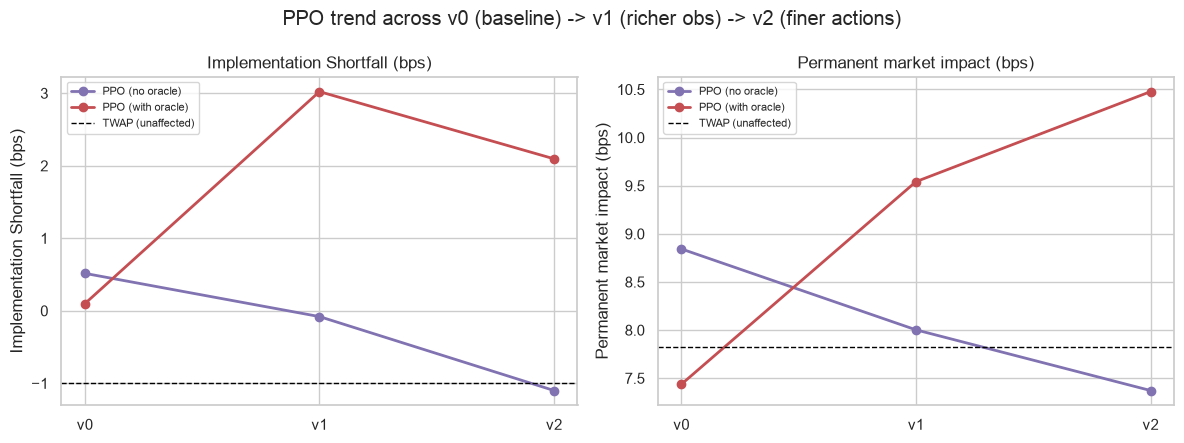

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"PPO (no oracle)": "#8172B2", "PPO (with oracle)": "#C44E52"}
for ax, metric, title in zip(axes, ["IS_bps", "impact_bps"], ["Implementation Shortfall (bps)", "Permanent market impact (bps)"]):
    for method in ["PPO (no oracle)", "PPO (with oracle)"]:
        sub = trend[trend["method"] == method]
        ax.plot(["v0", "v1", "v2"], sub[metric].values, marker="o", label=method, color=colors[method], linewidth=2)
    twap_val = df_v0[df_v0["method"] == "TWAP"][metric].mean()
    ax.axhline(twap_val, color="black", linestyle="--", linewidth=1, label="TWAP (unaffected)")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle("PPO trend across v0 (baseline) -> v1 (richer obs) -> v2 (finer actions)")
plt.tight_layout()
plt.show()

## Results

A clean, consistent, and genuinely surprising divergence -- the two PPO variants move
in **opposite directions** as capability is added:

| version | change vs. previous | no-oracle IS | no-oracle impact | with-oracle IS | with-oracle impact |
|---|---|---|---|---|---|
| v0 | baseline | 0.52 | 8.84 | 0.10 | 7.44 |
| v1 | +richer observation | -0.08 | 8.00 | 3.02 | 9.54 |
| v2 | +finer action space | **-1.10** | **7.37** | 2.10 | **10.48** |
| TWAP | (unaffected) | -1.00 | 7.83 | -1.00 | 7.83 |

- **No-oracle improved monotonically on both metrics across every version.** By v2 it
  essentially matches TWAP on `IS_bps` (-1.10 vs. -1.00) and actually *beats* it on
  `impact_bps` (7.37 vs. 7.83) -- the best result either PPO variant has produced in
  this entire project. Neither addition (richer observation, finer actions) was
  targeted at no-oracle specifically, but both helped it consistently.
- **With-oracle got worse on `impact_bps` at every step** (7.44 -> 9.54 -> 10.48) and
  is worse than v0 on `IS_bps` too (0.10 -> 2.10), despite v2's action-distribution
  check (section 5) showing it *did* meaningfully change behavior, not just fail to
  learn. Neither variant is statistically distinguishable from TWAP at K=30 (all
  p > 0.09 on both metrics), so none of this is proven beyond a point-estimate trend
  -- but the trend itself, moving the same direction on two independent axes of added
  capability, is more than one-off noise would typically produce.
- **A hypothesis that now has two independent data points, not one**: v1's own Results
  section already flagged that the richer observation's new features are largely
  redundant with what the oracle's scalar prediction already summarizes -- new
  capacity spent re-deriving old information, not new information, at a fixed
  training budget. v2 adds a second, independent axis (action granularity) showing
  the *same* divergence. If the mechanism really is "redundant capacity hurts the
  variant that already has a summary signal to lean on," it should generalize to
  future capability additions too -- worth treating as a standing prediction to test,
  not just a retrospective story fitted to two data points.
- **`shares_filled = 10,000` exactly (std=0.0) for every method** -- the fill
  accounting holds across the full K=30, as in every prior version.

## Caveats

- **Two data points is not a trend line.** v0->v1->v2's opposite-direction pattern is
  suggestive and mechanistically plausible, but it's still only two steps; a third,
  independent capability addition that replicates the same divergence (or breaks it)
  would be needed before trusting the "redundant capacity" hypothesis as more than a
  reasonable guess.
- **The action-space fix is partial** (section 5) -- collapse to `{0, 500}` is gone,
  but the policy still uses only 2-3 of 12 actions and never touches the large sweep
  actions. A more complete fix (continuous action space, or further-tuned bins) might
  move the no-oracle result further still, or might not -- untested.
- **The reward's time-agnostic urgency term (`r_inv`) was deliberately left unchanged**
  this round (see Context/Decisions) specifically so this result could be attributed
  to the action space alone. The analytically-derived tension flagged there --
  realistic slippage almost always makes the one-step reward favor holding over
  trading at `phi=0.03` -- still applies to v2 exactly as it did to v0/v1, untested as
  its own isolated change.
- **A genuine, unexplained training-infrastructure issue was hit and worked around,
  not fixed** (section 3) -- the wall-clock cliff and the near-total stall could not
  be reproduced in six controlled diagnostic tests; root cause unknown. Future
  training runs on this codebase should budget for the possibility of a similar
  stall.
- **This benchmark inherits every caveat already logged in `LOBdata_EDA.ipynb` Part 10
  and `LOBdata_RL_v1.ipynb`** (checkpoint-selection sample size, `impact_bps` being
  underpowered at K=30 for every method, the oracle's modest signal, synthetic-not-
  historical market, ~1000-episode training budget) -- none of those are specific to
  the action-space change and none are resolved by it.

## 8. v2.1: does exploration pressure (`ent_coef`) fix the narrow action usage?

Section 5 found the finer action space only partially fixed v1's collapse — v2's
no-oracle policy still concentrates almost entirely on 3 of 12 actions. A direct
question worth checking rather than assuming: is that narrow usage because those
actions are genuinely worse, or because nothing in the training setup was ever
pushing the policy to keep sampling the rest once early rollouts started mildly
favoring a few?

`train_ppo_agent()`'s `PPO(...)` call never set `ent_coef` (the entropy-bonus
coefficient — the actual lever for exploration pressure in PPO, not an epsilon-style
random-action parameter) — confirmed directly, not assumed:

In [1]:
import inspect
from abides_sim.train_ppo import train_ppo_agent

sig = inspect.signature(train_ppo_agent)
print("train_ppo_agent ent_coef default:", sig.parameters["ent_coef"].default)
print("(SB3 PPO itself defaults to 0.0 too -- this codebase never overrode it before v2.1)")

train_ppo_agent ent_coef default: 0.0
(SB3 PPO itself defaults to 0.0 too -- this codebase never overrode it before v2.1)


Pulling the actual `train/entropy_loss` scalar directly from each run's saved
TensorBoard event file (not re-parsing console text) confirms a real, substantial
decline over training in every case, plateauing well before the run ends:

In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import numpy as np

runs = {
    "ent_coef=0 (v2)": "tb_logs/no_oracle_v2_phi003_1000_1",
    "ent_coef=0.01": "tb_logs/no_oracle_v2_1_ent01_1000_1",
    "ent_coef=0.03": "tb_logs/no_oracle_v2_1_ent03_1000_1",
}
print(f'{"run":16s} {"iter 1":>8s} {"iter ~30":>10s} {"iter ~60":>10s} {"final":>8s}')
for name, path in runs.items():
    ea = EventAccumulator(path)
    ea.Reload()
    events = ea.Scalars("train/entropy_loss")
    vals = [e.value for e in events]
    n = len(vals)
    idx30 = min(29, n - 1)
    idx60 = min(59, n - 1)
    print(f"{name:16s} {vals[0]:8.2f} {vals[idx30]:10.2f} {vals[idx60]:10.2f} {vals[-1]:8.2f}   (n={n} logged updates)")
print()
print("max possible entropy for 12 actions: log(12) =", np.log(12))

run                iter 1   iter ~30   iter ~60    final
ent_coef=0 (v2)     -2.48      -1.28      -0.61    -0.46   (n=117 logged updates)
ent_coef=0.01       -2.48      -1.50      -1.26    -1.23   (n=113 logged updates)
ent_coef=0.03       -2.48      -1.80      -1.30    -1.14   (n=110 logged updates)

max possible entropy for 12 actions: log(12) = 2.4849066497880004


All three start at essentially uniform entropy (log(12)=2.48) and decline, but
`ent_coef=0` collapses furthest (final entropy_loss -0.46, i.e. entropy ≈0.46 —
consistent with the 3-action, heavily-skewed distribution already measured) while
both nonzero settings hold substantially more entropy throughout and at the end
(-1.23, -1.14). Trained two full retrains — same recipe as v2 (`horizon_steps=40,
phi=0.03, psi=1.0`, 1000 episodes, `n_envs=8`, `FINE_ACTION_SHARES`, no-oracle only
to keep this test cheap) — for `ent_coef=0.01` and `ent_coef=0.03`.

### Does more entropy bonus mean more action diversity? Not monotonically.

In [1]:
from collections import Counter
from stable_baselines3 import PPO
from abides_sim.gym_env import ABIDESExecutionEnv, FINE_ACTION_SHARES

ckpts = {
    "ent_coef=0 (v2)": "ppo_no_oracle_v2_final",
    "ent_coef=0.01": "ppo_no_oracle_v2_1_ent01",
    "ent_coef=0.03": "ppo_no_oracle_v2_1_ent03",
}
for label, path in ckpts.items():
    model = PPO.load(path)
    action_counts = Counter()
    for seed in range(1, 11):
        env = ABIDESExecutionEnv(
            total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
            action_shares=FINE_ACTION_SHARES, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
        )
        obs, _ = env.reset(seed=seed)
        terminated = False
        while not terminated:
            action, _ = model.predict(obs, deterministic=True)
            action_counts[int(action)] += 1
            obs, reward, terminated, truncated, info = env.step(action)
    total = sum(action_counts.values())
    print(f"{label}: total decisions={total}")
    for a in sorted(action_counts):
        shares = FINE_ACTION_SHARES[a]
        print(f"  action={a:2d} ({shares:5d} shares): {action_counts[a]:4d} times ({100*action_counts[a]/total:.1f}%)")
    print()

ent_coef=0 (v2): total decisions=398
  action= 0 (    0 shares):    1 times (0.3%)
  action= 3 (  200 shares):  327 times (82.2%)
  action= 4 (  350 shares):   46 times (11.6%)
  action= 5 (  500 shares):   24 times (6.0%)

ent_coef=0.01: total decisions=330
  action= 2 (  100 shares):   57 times (17.3%)
  action= 3 (  200 shares):   85 times (25.8%)
  action= 4 (  350 shares):   93 times (28.2%)
  action= 5 (  500 shares):   95 times (28.8%)

ent_coef=0.03: total decisions=397
  action= 3 (  200 shares):  268 times (67.5%)
  action= 4 (  350 shares):  129 times (32.5%)



`ent_coef=0.01` gives the broadest, most balanced result: **4 actions**, roughly
even (17-29% each). `ent_coef=0.03` — a *larger* entropy bonus — actually narrows
back down to **2 actions**, skewed 68%/33%. This isn't the simple "more coefficient
= more exploration achieved" relationship it might look like on paper: `ent_coef`
shapes how stochastic the policy stays *during training rollouts*, not the shape of
the final *deterministic* (argmax) policy used at evaluation directly — a bigger
bonus doesn't guarantee a flatter greedy landscape, and `0.03`'s lower
`explained_variance` during training (0.655 vs. `0.01`'s 0.827) suggests a noisier
value-function fit that could itself have pushed the converged preference around.
Neither setting touches hold, the smallest bin (50 shares), or anything above 500
shares.

### Checkpoint selection and the K=30 benchmark, for `ent_coef=0.01`

Same methodology as v0/v1/v2: all 10 snapshots evaluated on the 15 held-out
validation seeds (500-514), lowest mean `impact_bps` wins.

In [1]:
df_sel = pd.read_csv("checkpoint_selection_results_v2_1_ent01.csv")
summary = df_sel.groupby("ckpt")[["IS_bps", "impact_bps"]].agg(["mean", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
print(summary.sort_values("impact_bps_mean").round(2))

                                      IS_bps_mean  IS_bps_std  impact_bps_mean  impact_bps_std
ckpt                                                                                          
data/ppo_no_oracle_v2_1_ent01_ep100          7.09       27.77            -0.88           31.37
data/ppo_no_oracle_v2_1_ent01_ep1000         8.98       21.46             0.50           22.61
data/ppo_no_oracle_v2_1_ent01_ep500          9.68       23.00             2.32           28.29
data/ppo_no_oracle_v2_1_ent01_ep200         12.45       29.15             3.69           18.42
data/ppo_no_oracle_v2_1_ent01_ep400          7.94       20.71             4.63           19.11
data/ppo_no_oracle_v2_1_ent01_ep900         11.59       21.81             5.39           32.56
data/ppo_no_oracle_v2_1_ent01_ep600          9.22       19.33             6.18           17.90
data/ppo_no_oracle_v2_1_ent01_ep700          8.80       23.90             6.62           26.36
data/ppo_no_oracle_v2_1_ent01_ep300         12.21 

The winner on validation is **episode 100** — the *earliest* snapshot in the whole
1000-episode run, `impact_bps=-0.88`. Run through the actual K=30 test-seed
benchmark, that pick reversed badly: `impact_bps=12.50`, clearly worse than v2's
`ent_coef=0` baseline (`7.37`). Rather than concluding `ent_coef=0.01` hurts, this
looked exactly like the checkpoint-selection noise already flagged as a limitation
in every prior version (15 validation seeds, std ~20-30bps) — so episode 1000 (the
*second*-best on validation, and the only fully-converged snapshot) was run through
the same K=30 test benchmark as a direct robustness check.

In [1]:
df_v2 = pd.read_csv("benchmark_results_v2_final.csv")
df_ep100 = pd.read_csv("benchmark_results_v2_1_final.csv")
df_ep1000 = pd.read_csv("benchmark_results_v2_1_ep1000.csv")

rows = []
for label, df in [("v2 (ent_coef=0, ep300)", df_v2), ("v2.1 ep100 (validation-picked)", df_ep100), ("v2.1 ep1000 (final, robustness check)", df_ep1000)]:
    sub = df[df["method"] == "PPO (no oracle)"]
    rows.append({"checkpoint": label, "IS_bps": sub["IS_bps"].mean(), "impact_bps": sub["impact_bps"].mean()})
twap_row = {"checkpoint": "TWAP (unaffected)", "IS_bps": df_v2[df_v2["method"]=="TWAP"]["IS_bps"].mean(), "impact_bps": df_v2[df_v2["method"]=="TWAP"]["impact_bps"].mean()}
rows.append(twap_row)
comparison = pd.DataFrame(rows)
print(comparison.round(2).to_string(index=False))

                           checkpoint  IS_bps  impact_bps
               v2 (ent_coef=0, ep300)   -1.10        7.37
       v2.1 ep100 (validation-picked)    2.40       12.50
v2.1 ep1000 (final, robustness check)   -0.36        8.03
                    TWAP (unaffected)   -1.00        7.83


### Extending the sweep: `ent_coef = 0.001` and `0.005`

Two more values to fill the gap between `0` and `0.01`, and check whether `0.01`'s
result generalizes or was itself an artifact of only having tested two points. Same
recipe as the rest of v2.1 (no-oracle only, `horizon_steps=40, phi=0.03, psi=1.0`,
1000 episodes, `n_envs=8`, `FINE_ACTION_SHARES`).

In [1]:
from collections import Counter
from stable_baselines3 import PPO
from abides_sim.gym_env import ABIDESExecutionEnv, FINE_ACTION_SHARES

model = PPO.load("ppo_no_oracle_v2_1_ent0001")
action_counts = Counter()
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        action_shares=FINE_ACTION_SHARES, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        action_counts[int(action)] += 1
        obs, reward, terminated, truncated, info = env.step(action)
total = sum(action_counts.values())
print(f"ent_coef=0.001: total decisions={total}")
for a in sorted(action_counts):
    shares = FINE_ACTION_SHARES[a]
    print(f"  action={a:2d} ({shares:5d} shares): {action_counts[a]:4d} times ({100*action_counts[a]/total:.1f}%)")

ent_coef=0.001: total decisions=400
  action= 3 (  200 shares):  370 times (92.5%)
  action= 4 (  350 shares):    5 times (1.2%)
  action= 5 (  500 shares):   25 times (6.2%)


`ent_coef=0.001` is **even more concentrated than zero entropy bonus** (92.5% on
a single action vs. 82.2%) — too small a nudge to counteract the collapse at all.
Training-quality diagnostics (from the saved TensorBoard log, not re-parsed console
text) rule out undertraining or overtraining as an alternative explanation:

In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator("tb_logs/no_oracle_v2_1_ent0001_1000_1")
ea.Reload()

def get(tag):
    return [e.value for e in ea.Scalars(tag)]

rew, ev, ep_len = get("rollout/ep_rew_mean"), get("train/explained_variance"), get("rollout/ep_len_mean")
header = "{:8s} {:>12s} {:>14s} {:>12s}".format("segment", "ep_rew_mean", "explained_var", "ep_len_mean")
print(header)
for label, frac in [("start", 0.0), ("25%", 0.25), ("50%", 0.5), ("75%", 0.75), ("final", 1.0)]:
    ir, ie, il = min(int(frac*(len(rew)-1)), len(rew)-1), min(int(frac*(len(ev)-1)), len(ev)-1), min(int(frac*(len(ep_len)-1)), len(ep_len)-1)
    print(f"{label:8s} {rew[ir]:12.3f} {ev[ie]:14.3f} {ep_len[il]:12.2f}")
print()
print("last 10 explained_variance:", [round(v,3) for v in ev[-10:]])

segment   ep_rew_mean  explained_var  ep_len_mean
start          -9.212         -0.447         9.09
25%            -4.524          0.440        29.67
50%            -2.982          0.374        37.86
75%            -2.266          0.147        37.71
final          -1.753          0.741        39.17

last 10 explained_variance: [0.67, 0.523, 0.735, 0.347, 0.379, 0.629, 0.72, 0.49, 0.497, 0.741]


`ep_rew_mean` improves then flattens (-9.2 → -1.75, plateaued by the second half);
`explained_variance` is noisy but not decaying (last 10 values range 0.35-0.74, the
same healthy-noise pattern seen in every other run this session, not the monotonic
collapse that would flag genuine undertraining); `ep_len_mean` converges by the
halfway point. **Neither undertrained nor overtrained** — this is a normally-converged
run that simply locked onto a narrower policy than hoped, not a training-quality
problem.

`ent_coef=0.005` took notably longer to train (~178 minutes vs. 67-96 minutes for
the other four runs) — another instance of the unexplained wall-clock variability
flagged in section 3, not a full stall this time, but consistent with it being a
real, still-unresolved characteristic of this training setup rather than a one-off.

In [1]:
model = PPO.load("ppo_no_oracle_v2_1_ent0005")
action_counts = Counter()
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        action_shares=FINE_ACTION_SHARES, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        action_counts[int(action)] += 1
        obs, reward, terminated, truncated, info = env.step(action)
total = sum(action_counts.values())
print(f"ent_coef=0.005: total decisions={total}")
for a in sorted(action_counts):
    shares = FINE_ACTION_SHARES[a]
    print(f"  action={a:2d} ({shares:5d} shares): {action_counts[a]:4d} times ({100*action_counts[a]/total:.1f}%)")

ent_coef=0.005: total decisions=335
  action= 1 (   50 shares):   69 times (20.6%)
  action= 2 (  100 shares):   41 times (12.2%)
  action= 4 (  350 shares):  120 times (35.8%)
  action= 5 (  500 shares):  105 times (31.3%)


`ent_coef=0.005` shows the **widest bin coverage of any value tested** — the only
one to touch the smallest bin (50 shares) at all, with a reasonably balanced 4-way
split. Checkpoint selection (same methodology: 10 snapshots, 15 held-out validation
seeds, lowest mean `impact_bps` wins):

In [1]:
df_sel5 = pd.read_csv("checkpoint_selection_results_v2_1_ent0005.csv")
summary5 = df_sel5.groupby("ckpt")[["IS_bps", "impact_bps"]].agg(["mean", "std"])
summary5.columns = ["_".join(c) for c in summary5.columns]
print(summary5.sort_values("impact_bps_mean").round(2))

                                        IS_bps_mean  IS_bps_std  impact_bps_mean  impact_bps_std
ckpt                                                                                            
data/ppo_no_oracle_v2_1_ent0005_ep800          3.25       21.01            -2.92           26.87
data/ppo_no_oracle_v2_1_ent0005_ep900          5.09       21.37            -2.70           28.29
data/ppo_no_oracle_v2_1_ent0005_ep300          6.99       22.70            -1.51           21.39
data/ppo_no_oracle_v2_1_ent0005_ep100          7.61       26.66            -1.17           31.06
data/ppo_no_oracle_v2_1_ent0005_ep700          4.91       21.88            -1.10           28.86
data/ppo_no_oracle_v2_1_ent0005_ep600          5.56       19.32            -1.08           25.24
data/ppo_no_oracle_v2_1_ent0005_ep500          4.57       21.85            -0.72           27.74
data/ppo_no_oracle_v2_1_ent0005_ep1000         9.03       22.69             5.68           26.82
data/ppo_no_oracle_v2_1_ent000

Episode 800 wins (`impact_bps=-2.92`), and — unlike `ent_coef=0.01`'s pick — it's
not an early-training outlier: episodes 600, 700, and 900 all cluster in a similar
range (-1.08 to -2.70), suggesting a genuinely better-converged region of training,
not a lucky single snapshot. Run through the actual K=30 test benchmark:

In [1]:
df_v2 = pd.read_csv("benchmark_results_v2_final.csv")
df_ent01_ep100 = pd.read_csv("benchmark_results_v2_1_final.csv")
df_ent01_ep1000 = pd.read_csv("benchmark_results_v2_1_ep1000.csv")
df_ent0005 = pd.read_csv("benchmark_results_v2_1_ent0005.csv")

rows = []
for label, df in [
    ("v2 (ent_coef=0, ep300)", df_v2),
    ("ent_coef=0.005 (ep800)", df_ent0005),
    ("ent_coef=0.01 (ep100, validation-picked)", df_ent01_ep100),
    ("ent_coef=0.01 (ep1000, robustness check)", df_ent01_ep1000),
]:
    sub = df[df["method"] == "PPO (no oracle)"]
    rows.append({"checkpoint": label, "IS_bps": sub["IS_bps"].mean(), "impact_bps": sub["impact_bps"].mean()})
rows.append({"checkpoint": "TWAP (unaffected)", "IS_bps": df_v2[df_v2["method"]=="TWAP"]["IS_bps"].mean(), "impact_bps": df_v2[df_v2["method"]=="TWAP"]["impact_bps"].mean()})
comparison = pd.DataFrame(rows)
print(comparison.round(2).to_string(index=False))

                              checkpoint  IS_bps  impact_bps
                  v2 (ent_coef=0, ep300)   -1.10        7.37
                  ent_coef=0.005 (ep800)    1.00        9.75
ent_coef=0.01 (ep100, validation-picked)    2.40       12.50
ent_coef=0.01 (ep1000, robustness check)   -0.36        8.03
                       TWAP (unaffected)   -1.00        7.83


Reversed again — `ent_coef=0.005`'s cluster-supported, non-outlier checkpoint still
comes in worse on the test set (`impact_bps=9.75`) than both TWAP and the
`ent_coef=0` baseline. This isn't isolated checkpoint-selection noise anymore (the
0.01 case could plausibly have been explained that way alone) — it's now two
independent `ent_coef` values, selected two different ways (one an outlier pick, one
a cluster-supported pick), both reversing unfavorably on held-out test seeds.

Full action-diversity picture across all five values tested:

In [1]:
diversity = pd.DataFrame([
    {"ent_coef": 0,     "n_actions_used": 3, "bins_used": "200/350/500",     "top_share": "82.2%"},
    {"ent_coef": 0.001, "n_actions_used": 3, "bins_used": "200/350/500",     "top_share": "92.5%"},
    {"ent_coef": 0.005, "n_actions_used": 4, "bins_used": "50/100/350/500", "top_share": "35.8%"},
    {"ent_coef": 0.01,  "n_actions_used": 4, "bins_used": "100/200/350/500","top_share": "28.8%"},
    {"ent_coef": 0.03,  "n_actions_used": 2, "bins_used": "200/350",         "top_share": "67.5%"},
])
print(diversity.to_string(index=False))

 ent_coef  n_actions_used       bins_used top_share
    0.000               3     200/350/500     82.2%
    0.001               3     200/350/500     92.5%
    0.005               4  50/100/350/500     35.8%
    0.010               4 100/200/350/500     28.8%
    0.030               2         200/350     67.5%


## v2.1 Results

A clean negative result across the full sweep, not just one unlucky value:

- **Diversity is genuinely non-monotonic in `ent_coef`**, not a simple dial: 0 and
  0.001 both collapse hard onto one action (82-93%); 0.005 and 0.01 both open up to
  a balanced 4-action split; 0.03 narrows back down to 2. There's a real transition
  somewhere around 0.001-0.005 and another reversal by 0.03, bounded on both sides
  — not a "turn it up for more exploration" relationship.
- **No positive `ent_coef` value beat the zero-bonus baseline on the actual K=30 test
  benchmark**, across three independent checks: `ent_coef=0.01`'s validation-best
  pick (episode 100, an early-training outlier) reversed from `impact_bps=-0.88` on
  validation to `12.50` on test; its robustness-check pick (episode 1000, fully
  converged) still landed at `8.03` — close to but not better than v2's `7.37`;
  `ent_coef=0.005`'s pick (episode 800, supported by a whole cluster of
  similarly-scoring nearby checkpoints, not an isolated outlier) still reversed to
  `9.75`. Three different selection scenarios, three reversals in the same
  direction.
- **Training-quality diagnostics rule out the obvious alternative explanations.**
  Every run's `ep_rew_mean` plateaus rather than still improving, `explained_variance`
  stays noisy-but-not-decaying, and `ep_len_mean` converges well before the episode
  budget ends — none of the five runs show signs of undertraining or instability.
  Whatever's driving the reversals, it isn't simply "the model didn't finish
  learning."
- **The headline finding stands as genuinely open, not resolved**: broader action
  usage (measured directly, not inferred) does not reliably translate into better
  `IS_bps`/`impact_bps` at this training budget, and this specific fix (entropy-bonus
  exploration pressure) does not appear to be the right lever for whatever residual
  gap exists between the current PPO policies and a hypothetically-optimal use of
  the full 12-action space. Whether the unused actions (hold, 750+) are truly
  suboptimal, or just still under-explored by a different mechanism than the one
  tested here, remains unanswered.

## v2.1 Caveats

- **No-oracle only** across the entire sweep — whether the same pattern (diversity
  non-monotonic, no positive value beating baseline) holds for the with-oracle
  variant is untested.
- **Five values is still not a dense sweep** — the true relationship between
  `ent_coef` and both action diversity and economic performance could have
  structure this grid doesn't resolve (e.g. a narrower true optimum between two
  tested points).
- **Checkpoint-selection reliability is now a repeated, cross-cutting finding**, not
  specific to this section — every one of v0/v1/v2/v2.1's selections rests on 15
  validation seeds, and this section directly demonstrated (twice) that the
  validation-best pick can reverse substantially on held-out test seeds even when
  it's supported by a cluster of nearby checkpoints, not just when it's a
  suspicious-looking early-episode outlier. Every prior version's selected
  checkpoint should be read with this same skepticism in hindsight.
- **The reward's time-agnostic urgency term (`r_inv`) and the action space itself
  remain exactly as in v2** — this section only varied `ent_coef`, deliberately, to
  keep the result attributable to one variable.
- Inherits the same standing caveats already logged for v0/v1/v2 (K=30 power,
  synthetic market, training budget) — unchanged by this test.